# AG-HYPOPT · Trial 04

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Three trials recorded; best is trial 02 (0.0246). Trial 01 (lr_mu 10.09, sigma_ref 10.25, lr_gamma 0.52, gamma_anneal 0.10) scored 0.0981 and was mu-limited (mu -34% to -47%). Trial 02 (lr_mu 25.36, sigma_ref 6.84, lr_gamma 0.44, gamma_anneal 0.20) scored 0.0246: the high lr_mu cut mu rel RMSE 39.8% -> 17.5%. Trial 03 (lr_mu 23.05, sigma_ref 9.37, lr_gamma 0.79, gamma_anneal 0.22) scored 0.0477: raising lr_gamma left gamma flat (13.7% in both 02 and 03) while the mu-regime change pushed mu back to 27.7%. Findings so far: mu tracks lr_mu and sigma_ref (higher lr_mu, lower sigma_ref is better), gamma is insensitive to lr_gamma, and the residual error sits at low signal (Trans05, mu about -31% at best). Still in the uniform-design phase (3/5 done).]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_04'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (3/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.7072920791792757, "lr_gamma": 0.6090620422514893, "lr_mu": 29.406092642692602, "sigma_ref": 6.616720477912043}
 2 |      - | {"gamma_anneal": 0.4555168739962722, "lr_gamma": 0.5011892675018181, "lr_mu": 25.047530174645182, "sigma_ref": 8.490556322880568}
 3 |      - | {"gamma_anneal": 0.6537264556407423, "lr_gamma": 0.6351531206107985, "lr_mu": 27.55537699289971, "sigma_ref": 14.543070476784125}
 4 |      - | {"gamma_anneal": 0.32287220829705987, "lr_gamma": 0.8311573740354636, "lr_mu": 29.603824998278036, "sigma_ref": 12.394515853048576}
 5 |      - | {"gamma_anneal": 0.7266996519871762, "lr_gamma": 0.9432211102123356, "lr_mu": 9.442314644049528, "sigma_ref": 17.177032336890953}
 6 |      - | {"gamma_anneal": 0.5286485591735569, "lr_gamma": 0.9542429433033337, "lr_mu": 21.641435424143836, "sigma_ref": 7.667915109033863}
 7 |      - | {"gamma_anneal": 0.37340069908903084, "lr_gamma": 0.5948958671648918,

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best is trial 02 (0.0246, lr_mu 25.36, sigma_ref 6.84). The two trials after trial 01 bracket lr_mu at 10 (bad) and 25 (best), and trial 03 lowered it to 23 with sigma_ref up at 9.37 and got worse, so within this range higher lr_mu at low sigma_ref is the winning direction. The most informative next probe is therefore to push lr_mu to the top of its range while keeping sigma_ref low. Candidate 1 (lr_mu 29.41, sigma_ref 6.62, lr_gamma 0.61, gamma_anneal 0.71) does exactly that: it holds sigma_ref at trial 02's winning value (~6.7) and raises lr_mu the most of any candidate, testing whether the lr_mu optimum is beyond 25 or whether 25-26 was already near-peak. Its gamma_anneal is higher (0.71 vs 0.20), a confound I accept because no candidate isolates lr_mu perfectly; candidate 2 (lr_mu 25.05, sigma_ref 8.49) would nearly replicate trial 02 and carry little information, and candidates 3/4 pair high lr_mu with much higher sigma_ref. I choose candidate 1.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1               # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.7072920791792757, 'lr_gamma': 0.6090620422514893, 'lr_mu': 29.406092642692602, 'sigma_ref': 6.616720477912043}
Running  1nW Trans05 ... 

μ 9.39 -> 6.78 | γ 8.5 -> 7.24 | NLL 1.35


Running  1nW Trans20 ... 

μ 17.32 -> 15.87 | γ 8.5 -> 8.50 | NLL 2.70


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 100.86 | γ 14.1 -> 14.24 | NLL 3.39


Running 3nW Trans100 ... 

μ 175.71 -> 166.34 | γ 14.1 -> 14.26 | NLL 2.91



Total: 6.9 min


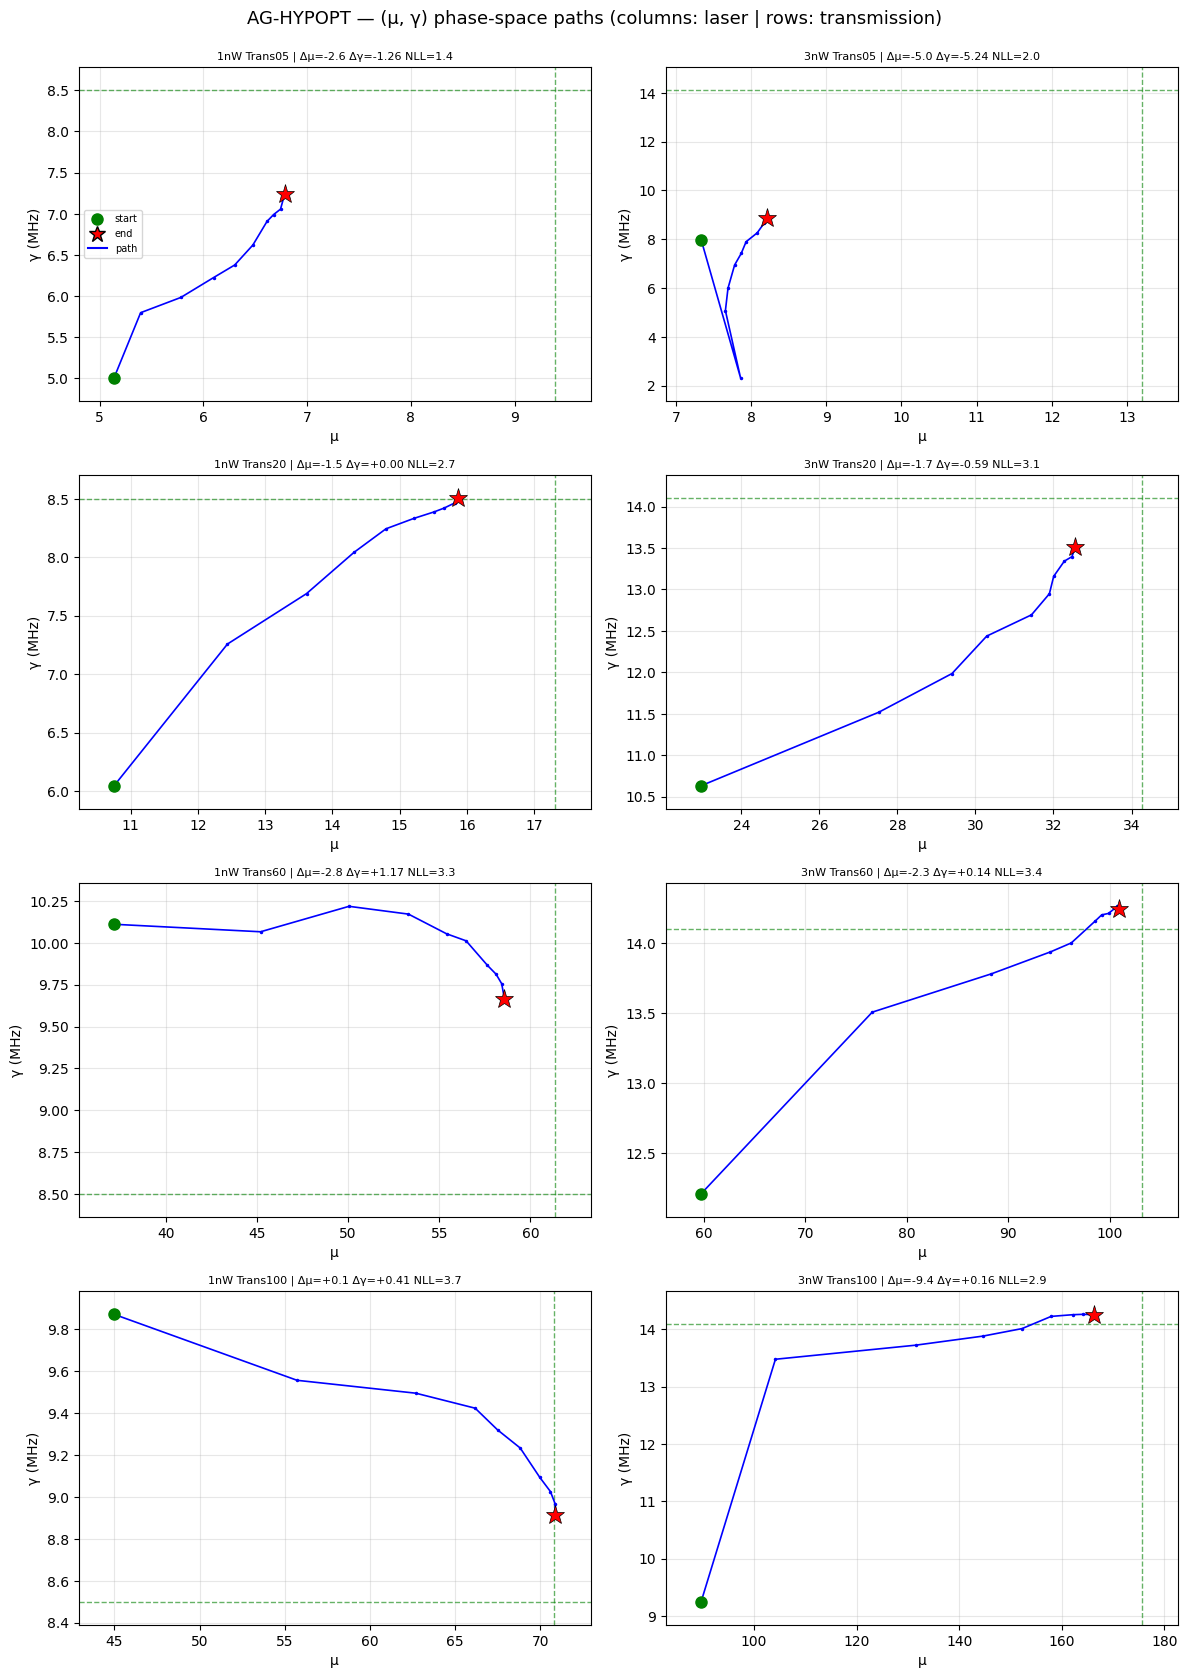

trial finished in 6.9 min
objective = 0.0262 ± 0.0122
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    6.78   -27.8 |     8.50    7.24   -14.8
1nW Trans20    17.32   15.87    -8.4 |     8.50    8.50    +0.1
1nW Trans60    61.37   58.58    -4.6 |     8.50    9.67   +13.7
1nW Trans100   70.82   70.87    +0.1 |     8.50    8.91    +4.9
3nW Trans05    13.20    8.21   -37.8 |    14.10    8.86   -37.2
3nW Trans20    34.28   32.56    -5.0 |    14.10   13.51    -4.2
3nW Trans60   103.20  100.86    -2.3 |    14.10   14.24    +1.0
3nW Trans100  175.71  166.34    -5.3 |    14.10   14.26    +1.1

μ: RMSE 4.152 (rel 17.2%, bias -3.154) | γ: RMSE 1.969 (rel 15.1%, bias -0.650)


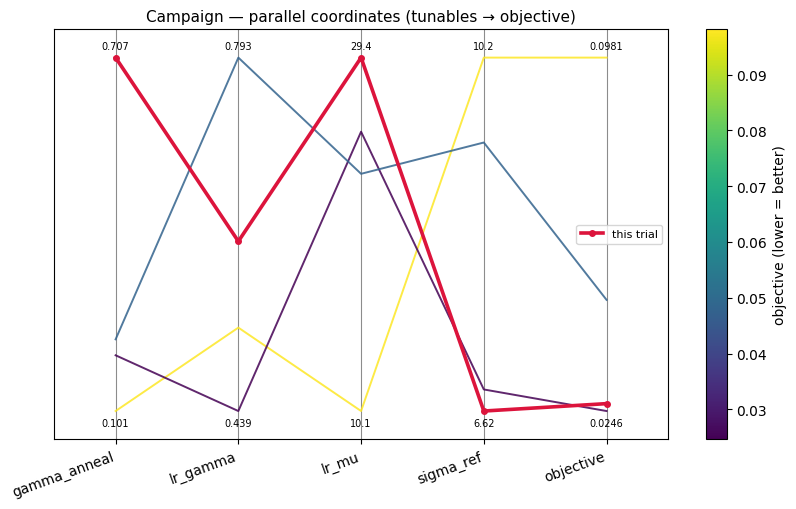

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 04 (sigma_ref 6.62, lr_mu 29.41, lr_gamma 0.61, gamma_anneal 0.71) ran 6.9 min and scored 0.0262 +/- 0.0122, essentially a tie with trial 02 (0.0246), which therefore stays nominally best. mu rel RMSE is 17.2%, unchanged from trial 02's 17.5% (bias -3.2 vs -5.8), so pushing lr_mu from 25.4 to 29.4 beyond the winning value gave no further mu gain - the mu optimum is at or below ~25. The mu wins remain the high-transmission points (1nW Trans100 +0.1%, 3nW Trans60 -2%, Trans100 -5%), with the persistent weak spot at Trans05 (-28% at 1nW, -38% at 3nW). gamma regressed slightly: rel RMSE 13.7% -> 15.1% (bias -0.65), driven by 3nW Trans05 (-37%) and 1nW Trans60 (+14%). Since sigma_ref and lr_mu are near trial 02's values, the gamma regression is most plausibly the much higher gamma_anneal (0.71 vs 0.20) and/or lr_gamma 0.61 vs 0.44, pointing to low gamma_anneal as favourable. Net: trial 04 does not beat trial 02; lr_mu is saturated near 25.

**Summary:** Trial 04 (sigma_ref 6.62, lr_mu 29.41, lr_gamma 0.61, gamma_anneal 0.71) scored 0.0262 +/- 0.0122, a near-tie with but not better than trial 02: lr_mu past 25 gave no mu gain (17.2% vs 17.5%) while gamma slipped to 15.1% (3nW Trans05 -37%).
**Key insight:** mu saturates at lr_mu ~25 (29 adds nothing), and the gamma regression at higher gamma_anneal (0.71) points to low gamma_anneal being better.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 04 (sigma_ref 6.62, lr_mu 29.41, lr_gamma 0.61, gamma_anneal 0.71) scored 0.0262 +/- 0.0122, a near-tie with but not better than trial 02: lr_mu past 25 gave no mu gain (17.2% vs 17.5%) while gamma slipped to 15.1% (3nW Trans05 -37%).'
KEY_INSIGHT = 'mu saturates at lr_mu ~25 (29 adds nothing), and the gamma regression at higher gamma_anneal (0.71) points to low gamma_anneal being better.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_04 | current best: trial_02


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_05.ipynb. Open it and follow its cells from the top.
